In [1]:
# ==========================================
# Credit Card Approval Prediction
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ==========================================
# Load Dataset
# ==========================================

application = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print("Application Dataset Shape:", application.shape)
print("Credit Dataset Shape:", credit.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


In [3]:
# First 5 rows of Application Dataset
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
# First 5 rows of Credit Dataset
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
application.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [6]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 25.0 MB


In [7]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [8]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [9]:
print("Application Duplicates:", application.duplicated().sum())
print("Credit Duplicates:", credit.duplicated().sum())

Application Duplicates: 0
Credit Duplicates: 0


In [10]:
application.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [11]:
application.describe(include="object")

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,438557,438557,438557,438557,438557,438557,438557,304354
unique,2,2,2,5,5,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,294440,275459,304074,226104,301821,299828,393831,78240


In [12]:
# ==========================================
# Create Target Variable
# ==========================================

# Customers with serious overdue history
bad_status = ['2', '3', '4', '5']

credit['TARGET'] = credit['STATUS'].apply(
    lambda x: 0 if x in bad_status else 1
)

credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,1
1,5001711,-1,0,1
2,5001711,-2,0,1
3,5001711,-3,0,1
4,5001712,0,C,1


In [13]:
# ==========================================
# Aggregate Target by Customer ID
# ==========================================

target_df = credit.groupby('ID')['TARGET'].min().reset_index()

target_df.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1


In [14]:
# ==========================================
# Merge Application and Target
# ==========================================

df = application.merge(target_df, on='ID', how='inner')

print(df.shape)

df.head()

(36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1


In [15]:
df['TARGET'].value_counts()

TARGET
1    35841
0      616
Name: count, dtype: int64

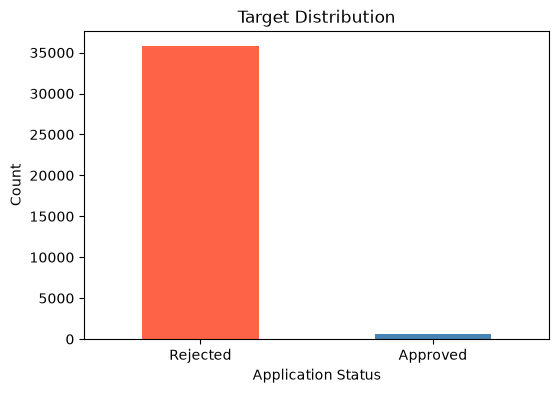

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df['TARGET'].value_counts().plot(
    kind='bar',
    color=['tomato','steelblue']
)

plt.xticks([0,1],['Rejected','Approved'], rotation=0)

plt.title("Target Distribution")

plt.xlabel("Application Status")

plt.ylabel("Count")

plt.show()

In [17]:
# ==========================================
# Missing Values
# ==========================================

df.isnull().sum().sort_values(ascending=False)

OCCUPATION_TYPE        11323
CODE_GENDER                0
ID                         0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
AMT_INCOME_TOTAL           0
CNT_CHILDREN               0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
NAME_INCOME_TYPE           0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_WORK_PHONE            0
FLAG_MOBIL                 0
FLAG_PHONE                 0
FLAG_EMAIL                 0
CNT_FAM_MEMBERS            0
TARGET                     0
dtype: int64

In [18]:
# ==========================================
# Fill Missing Values
# ==========================================

df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

print(df.isnull().sum().sum())

0


In [19]:
# ==========================================
# Remove Duplicate Records
# ==========================================

print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After :", df.shape)

Before: (36457, 19)
After : (36457, 19)


In [20]:
# ==========================================
# Convert Age
# ==========================================

df['AGE'] = (-df['DAYS_BIRTH']) // 365

df[['DAYS_BIRTH','AGE']].head()

,DAYS_BIRTH,AGE
0,-12005,32
1,-12005,32
2,-21474,58
3,-19110,52
4,-19110,52


In [21]:
# ==========================================
# Convert Employment Years
# ==========================================

df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

df['YEARS_EMPLOYED'] = (-df['YEARS_EMPLOYED']) / 365

df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].fillna(0)

df[['DAYS_EMPLOYED','YEARS_EMPLOYED']].head()

,DAYS_EMPLOYED,YEARS_EMPLOYED
0,-4542,12.443836
1,-4542,12.443836
2,-1134,3.106849
3,-3051,8.358904
4,-3051,8.358904


In [22]:
# ==========================================
# Drop Unnecessary Columns
# ==========================================

df.drop(
    columns=[
        'DAYS_BIRTH',
        'DAYS_EMPLOYED'
    ],
    inplace=True
)

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,1,32,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,1,32,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,1,58,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52,8.358904


In [23]:
print(df.shape)

df.head()

(36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,1,32,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,1,32,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,1,58,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,1,52,8.358904


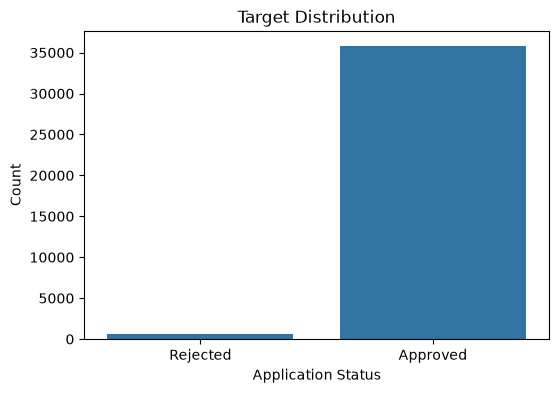

In [24]:
# ==========================================
# Target Distribution
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Target Distribution")
plt.xlabel("Application Status")
plt.ylabel("Count")

plt.xticks([0,1],["Rejected","Approved"])

plt.show()

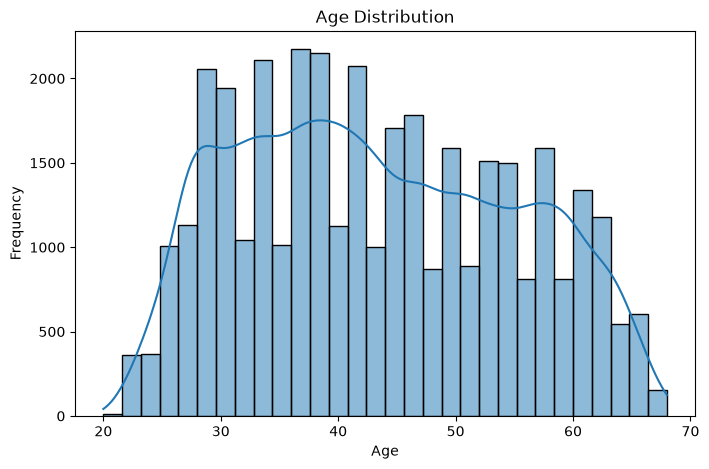

In [25]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df['AGE'], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

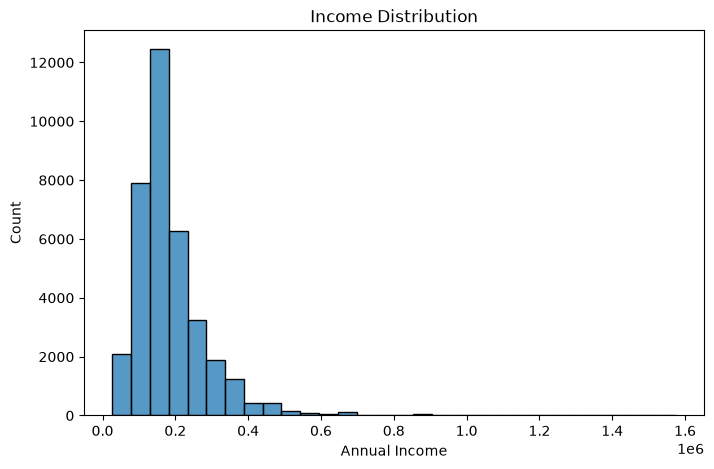

In [26]:
# ==========================================
# Income Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df['AMT_INCOME_TOTAL'], bins=30)

plt.title("Income Distribution")

plt.xlabel("Annual Income")

plt.ylabel("Count")

plt.show()

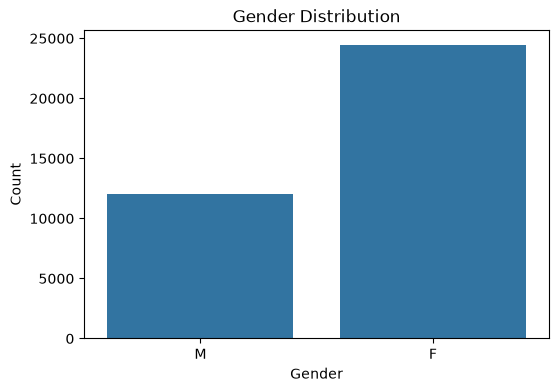

In [27]:
# ==========================================
# Gender Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='CODE_GENDER', data=df)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

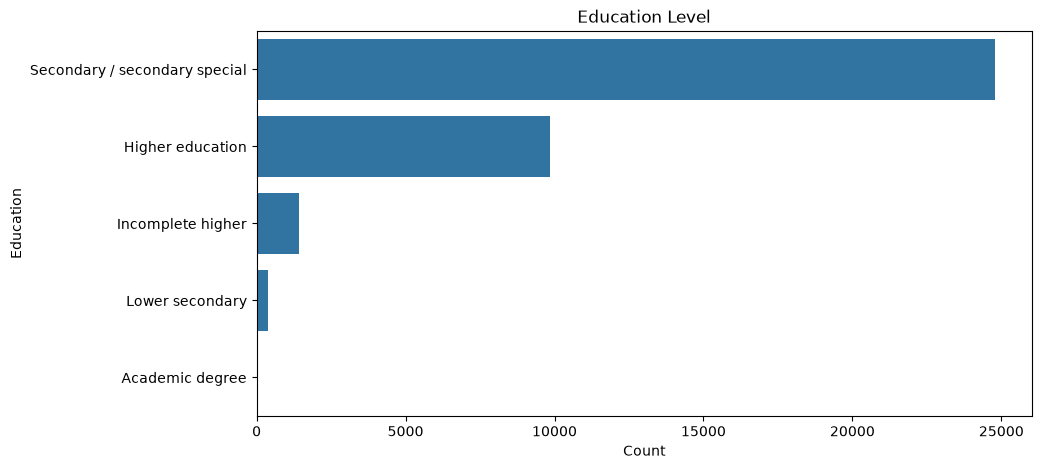

In [28]:
# ==========================================
# Education Level
# ==========================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='NAME_EDUCATION_TYPE',
    data=df,
    order=df['NAME_EDUCATION_TYPE'].value_counts().index
)

plt.title("Education Level")

plt.xlabel("Count")

plt.ylabel("Education")

plt.show()

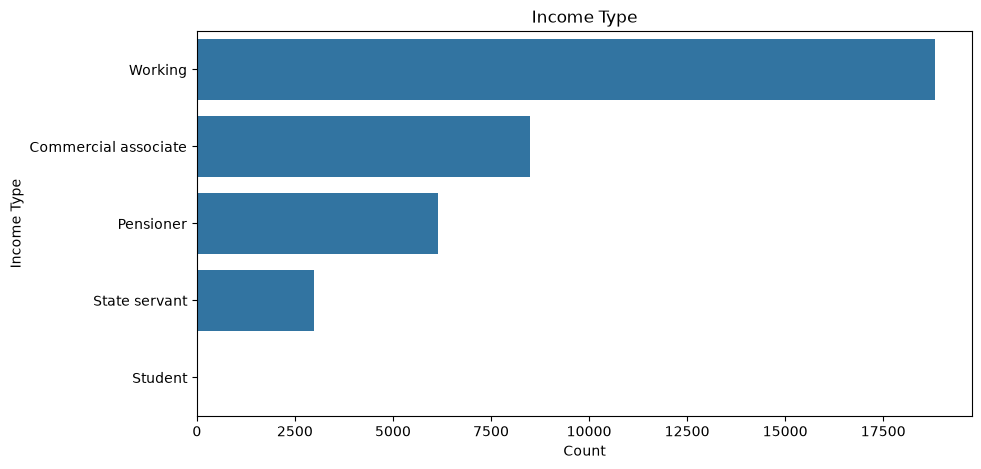

In [29]:
# ==========================================
# Income Type
# ==========================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='NAME_INCOME_TYPE',
    data=df,
    order=df['NAME_INCOME_TYPE'].value_counts().index
)

plt.title("Income Type")

plt.xlabel("Count")

plt.ylabel("Income Type")

plt.show()

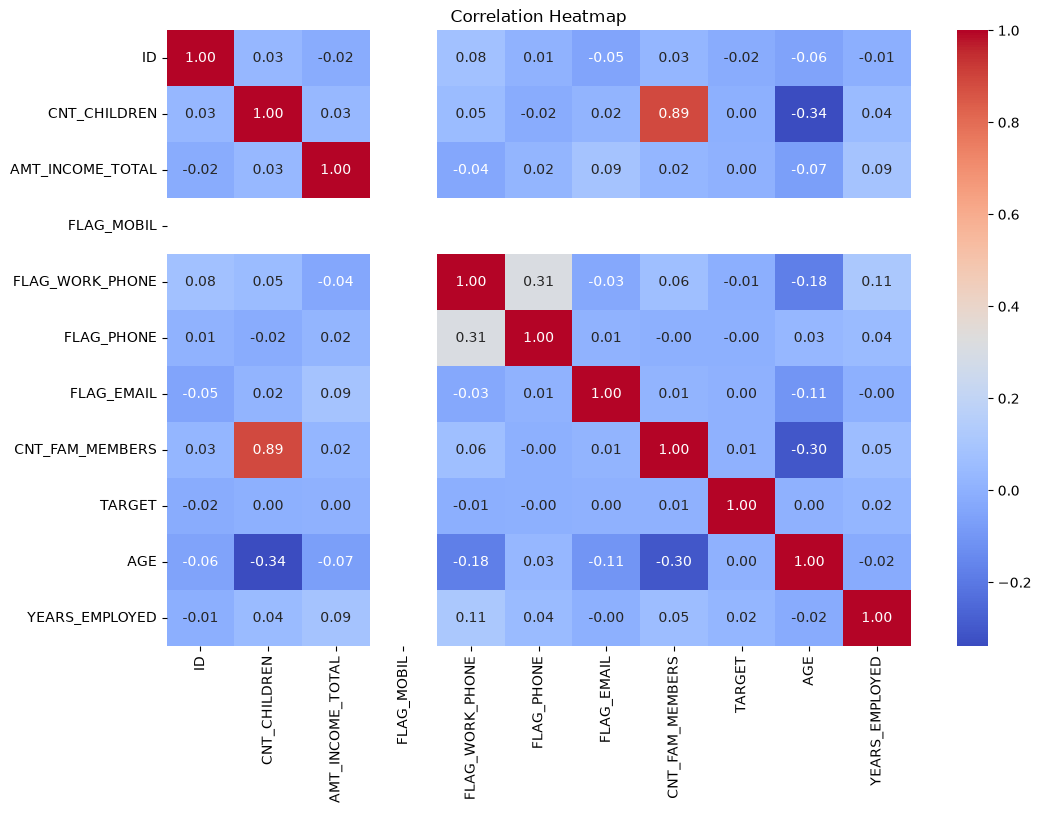

In [30]:
# ==========================================
# Correlation Heatmap
# ==========================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

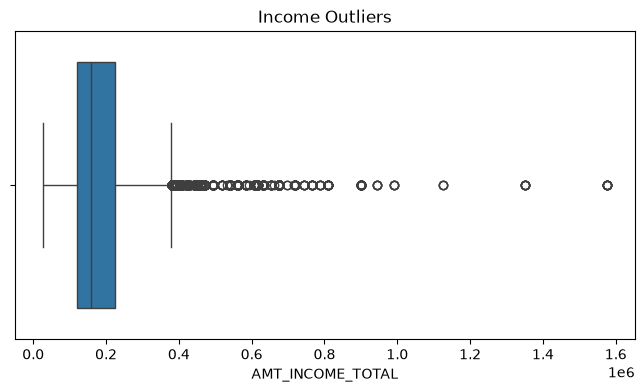

In [31]:
# ==========================================
# Income Outliers
# ==========================================

plt.figure(figsize=(8,4))

sns.boxplot(x=df['AMT_INCOME_TOTAL'])

plt.title("Income Outliers")

plt.show()

## EDA Observations

- The merged dataset contains **36,457** customer records.
- The target variable is highly imbalanced, with significantly more approved than rejected applications.
- Most applicants are between **30 and 50 years** of age.
- Working professionals represent the largest income group.
- Income contains a few high-value outliers.
- Numerical features show low to moderate correlations, indicating limited multicollinearity.

In [32]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (36457, 18)
Target Shape  : (36457,)


In [33]:
# ==========================================
# Encode Categorical Columns
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column].astype(str))
    label_encoders[column] = le

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [34]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

Scaling completed!


In [35]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (29165, 18)
Testing Shape  : (7292, 18)


In [36]:
# ==========================================
# Balance Dataset using SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(y_train.value_counts())

After SMOTE
TARGET
1    28672
0    28672
Name: count, dtype: int64


In [37]:
# ==========================================
# Import Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Models imported successfully!")

Models imported successfully!


In [38]:
# ==========================================
# Logistic Regression
# ==========================================

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [39]:
# ==========================================
# Decision Tree
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [40]:
# ==========================================
# Random Forest
# ==========================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [41]:
# ==========================================
# XGBoost
# ==========================================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [42]:
# ==========================================
# Evaluation Function
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred):
    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

In [43]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("XGBoost", y_test, xgb_pred)

Logistic Regression
Accuracy : 0.5626714207350522
Precision: 0.9863147605083089
Recall   : 0.5629794950481238
F1 Score : 0.7168102299973359

Decision Tree
Accuracy : 0.9698299506308283
Precision: 0.9872388164352826
Recall   : 0.9820058585576789
F1 Score : 0.9846153846153847

Random Forest
Accuracy : 0.9777838727372463
Precision: 0.9868000555787133
Recall   : 0.9906542056074766
F1 Score : 0.9887233746345538

XGBoost
Accuracy : 0.9775095995611629
Precision: 0.9877454393538504
Recall   : 0.9893988003905705
F1 Score : 0.9885714285714285



In [44]:
# ==========================================
# Model Comparison
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.977784,0.986800,0.990654,0.988723
3,XGBoost,0.977510,0.987745,0.989399,0.988571
1,Decision Tree,0.969830,0.987239,0.982006,0.984615
0,Logistic Regression,0.562671,0.986315,0.562979,0.716810


In [45]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.29      0.23      0.26       123
           1       0.99      0.99      0.99      7169

    accuracy                           0.98      7292
   macro avg       0.64      0.61      0.62      7292
weighted avg       0.98      0.98      0.98      7292



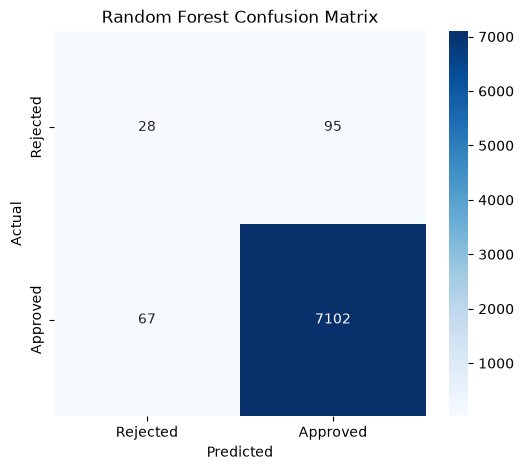

In [46]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Approved'],
    yticklabels=['Rejected','Approved']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [47]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,ID,0.123660
5,AMT_INCOME_TOTAL,0.112986
16,AGE,0.104762
14,OCCUPATION_TYPE,0.102043
17,YEARS_EMPLOYED,0.081801
8,NAME_FAMILY_STATUS,0.066681
6,NAME_INCOME_TYPE,0.062697
15,CNT_FAM_MEMBERS,0.049924
3,FLAG_OWN_REALTY,0.047887
2,FLAG_OWN_CAR,0.044292


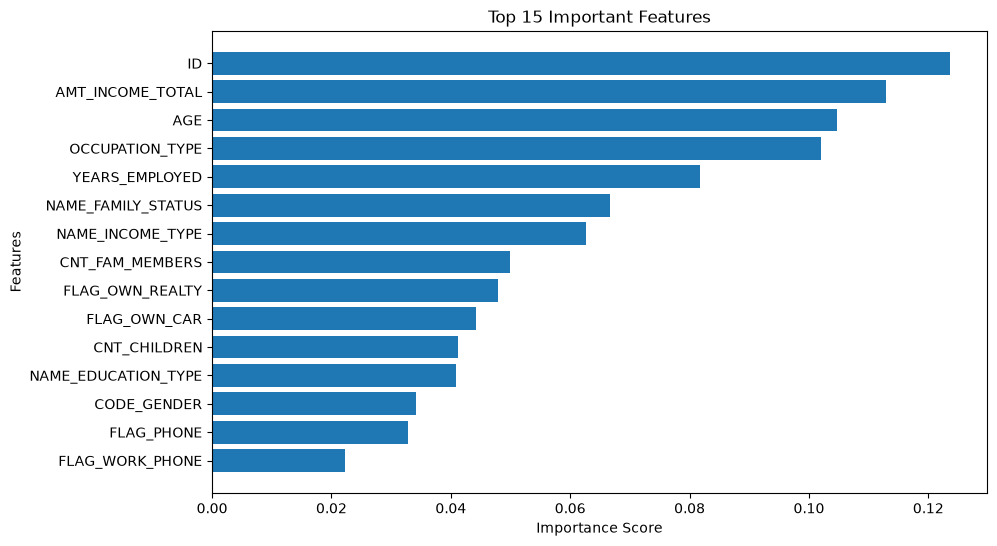

In [48]:
# ==========================================
# Top 15 Important Features
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [49]:
# ==========================================
# Save Model
# ==========================================

import joblib

joblib.dump(rf, "../saved_models/model.pkl")

joblib.dump(scaler, "../saved_models/scaler.pkl")

joblib.dump(label_encoders, "../saved_models/label_encoders.pkl")

print("Model saved successfully!")

Model saved successfully!


# Building Deployment Pipeline

In [50]:
# ==========================================
# Prepare Data for Deployment Pipeline
# ==========================================

# Fresh copy of dataset
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

print(X.shape)
print(y.shape)

(36457, 18)
(36457,)


In [51]:
# ==========================================
# Identify Feature Types
# ==========================================

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Numerical Features
['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Pipeline Created Successfully!")

Pipeline Created Successfully!


In [64]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance only the training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)
print(y_train.value_counts())

ValueError: could not convert string to float: 'M'

In [55]:
pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


In [56]:
from sklearn.metrics import accuracy_score

pred = pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))

Accuracy : 0.9746297312122875


In [57]:
import joblib

joblib.dump(pipeline, "../saved_models/pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [58]:
print(X.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']


In [63]:
df["TARGET"].value_counts(normalize=True)

TARGET
1    0.983103
0    0.016897
Name: proportion, dtype: float64